# Borrower Risk Intelligence System
## Notebook 4 — SHAP Explainability

**Objective:** Understand why the model makes each prediction. A risk score without an explanation is not useful in lending — a lender needs to know which factors drove a borrower's risk rating before making a decision.

---

**Contents**
1. Setup
2. Compute SHAP values
3. Global feature importance
4. Beeswarm plot
5. Waterfall plots — single borrower explanation
6. Dependence plots
7. High vs low risk borrower comparison
8. Risk scoring framework
9. Summary

## 1 — Setup

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'shap', 'xgboost', '-q'], check=True)

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/borrower-risk-intelligence/data'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
shap.initjs()

X_test = pd.read_csv(f'{DATA_DIR}/X_test.csv')
y_test = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

with open(f'{DATA_DIR}/feature_list.pkl', 'rb') as f:
    feature_list = pickle.load(f)

with open(f'{DATA_DIR}/xgboost_final.pkl', 'rb') as f:
    model = pickle.load(f)

with open(f'{DATA_DIR}/best_threshold.pkl', 'rb') as f:
    best_threshold = pickle.load(f)

X_test = X_test[feature_list]

print(f'X_test shape   : {X_test.shape}')
print(f'Best threshold : {best_threshold}')

X_test shape   : (61503, 95)
Best threshold : 0.6599999999999997


## 2 — Compute SHAP Values

Using a 2,000-row sample. SHAP on the full test set would take 30+ minutes — 2,000 rows is sufficient for stable global explanations.

In [3]:
np.random.seed(42)
sample_idx  = np.random.choice(len(X_test), size=2000, replace=False)
X_sample    = X_test.iloc[sample_idx].reset_index(drop=True)
y_sample    = y_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (2000, 95)


## 3 — Global Feature Importance

Mean absolute SHAP value per feature — how much each feature contributes to predictions on average across all borrowers.

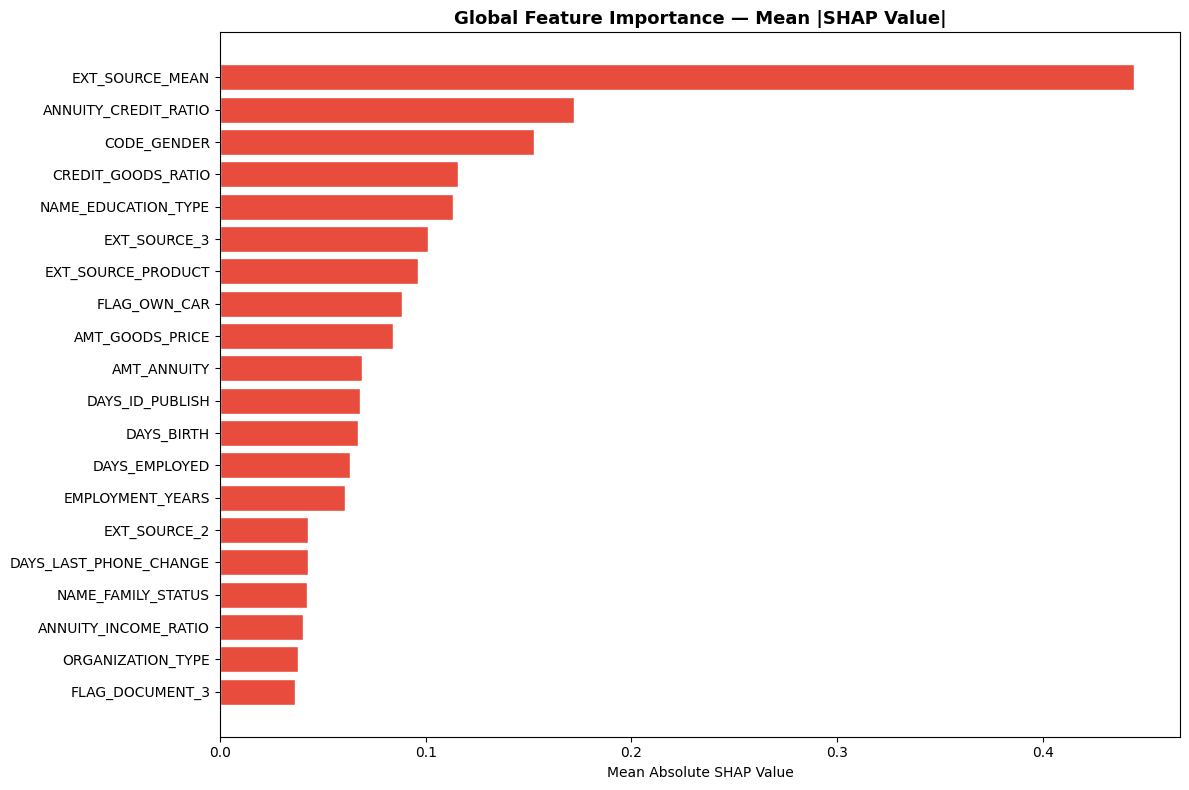

             Feature  Mean |SHAP|
     EXT_SOURCE_MEAN     0.444277
ANNUITY_CREDIT_RATIO     0.172306
         CODE_GENDER     0.152799
  CREDIT_GOODS_RATIO     0.115695
 NAME_EDUCATION_TYPE     0.113466
        EXT_SOURCE_3     0.101307
  EXT_SOURCE_PRODUCT     0.096193
        FLAG_OWN_CAR     0.088547
     AMT_GOODS_PRICE     0.084073
         AMT_ANNUITY     0.069141


In [4]:
shap_importance = pd.DataFrame({
    'Feature'    : feature_list,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(20)

plt.figure(figsize=(12, 8))
plt.barh(shap_importance['Feature'], shap_importance['Mean |SHAP|'],
         color='#e74c3c', edgecolor='white')
plt.title('Global Feature Importance — Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.xlabel('Mean Absolute SHAP Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(shap_importance.head(10).to_string(index=False))

## 4 — Beeswarm Plot

Each dot is one borrower. Red = high feature value, blue = low. Position on x-axis shows whether the feature pushed the prediction toward default (positive) or away from it (negative).

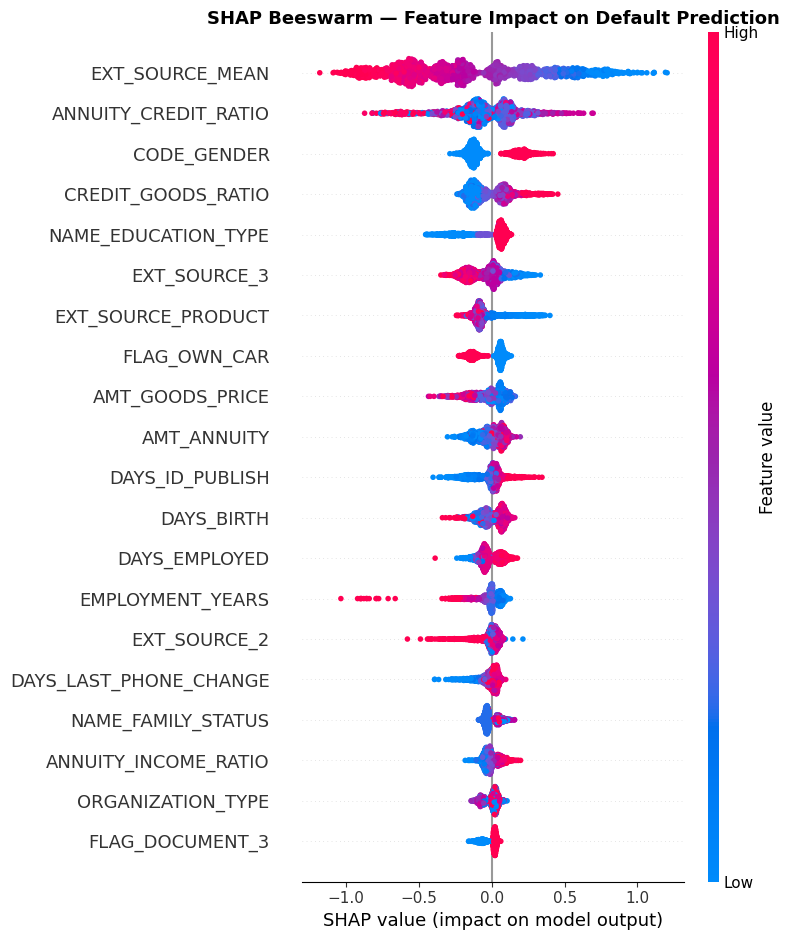

In [5]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Default Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Waterfall Plots — Single Borrower Explanation

Shows exactly which features drove one borrower's risk score up or down. This is what gets shown to a loan officer making a decision.

In [6]:
y_prob_sample = model.predict_proba(X_sample)[:, 1]

high_risk_idx = np.argmax(y_prob_sample)
low_risk_idx  = np.argmin(y_prob_sample)

print(f'High-risk borrower — P(default) : {y_prob_sample[high_risk_idx]:.4f}')
print(f'Low-risk borrower  — P(default) : {y_prob_sample[low_risk_idx]:.4f}')

High-risk borrower — P(default) : 0.9301
Low-risk borrower  — P(default) : 0.0076


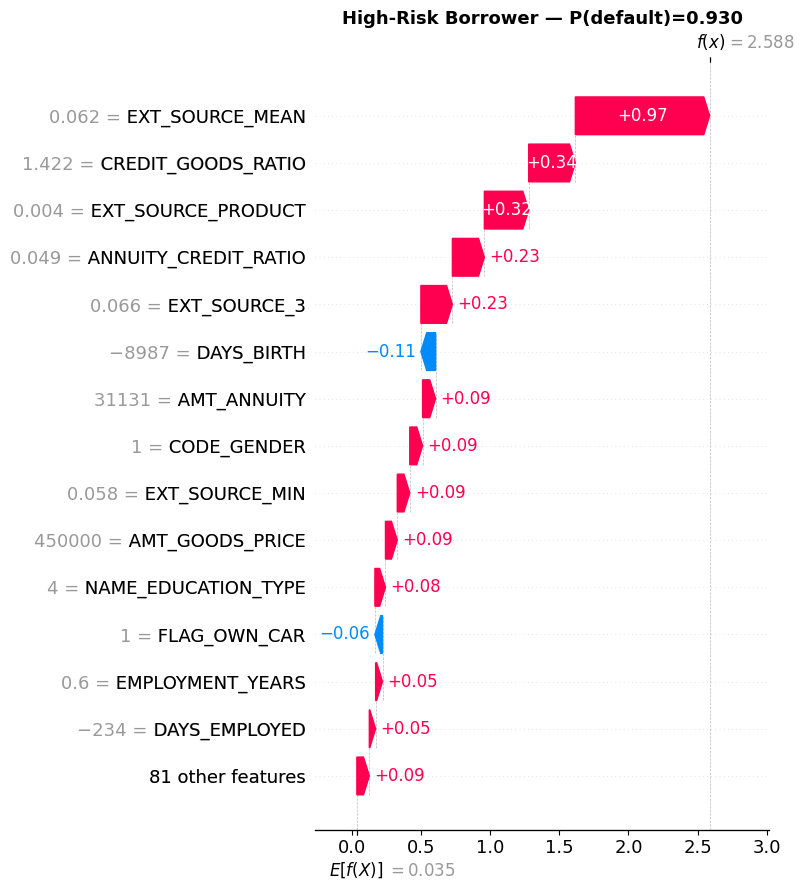

In [7]:
explanation = shap.Explanation(
    values        = shap_values,
    base_values   = explainer.expected_value,
    data          = X_sample.values,
    feature_names = feature_list
)

plt.figure(figsize=(14, 6))
shap.waterfall_plot(explanation[high_risk_idx], max_display=15, show=False)
plt.title(f'High-Risk Borrower — P(default)={y_prob_sample[high_risk_idx]:.3f}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

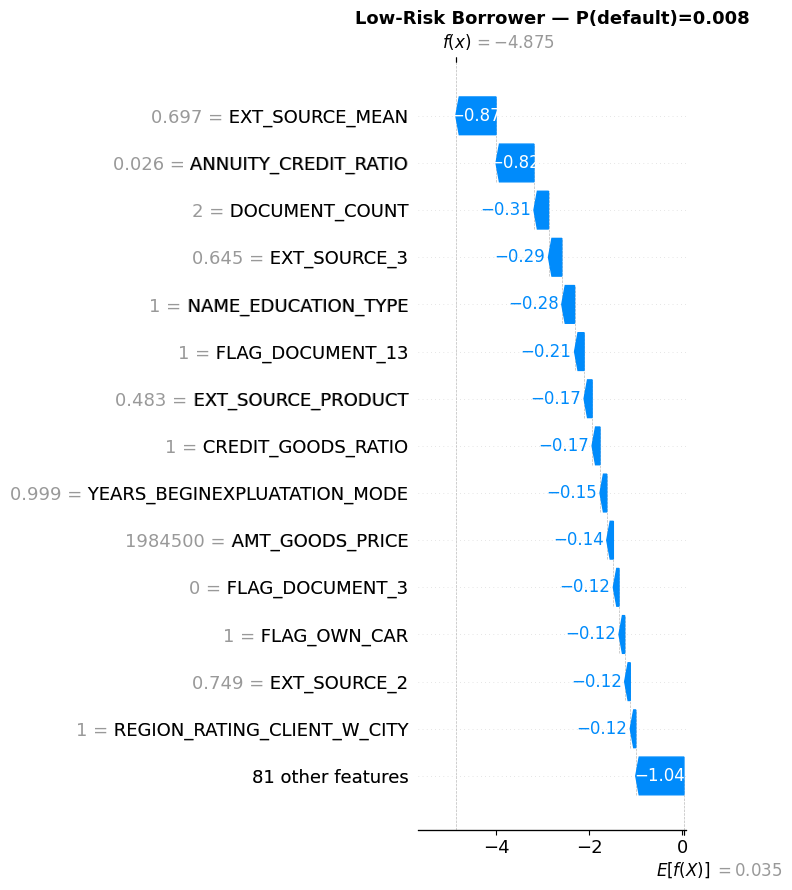

In [8]:
plt.figure(figsize=(14, 6))
shap.waterfall_plot(explanation[low_risk_idx], max_display=15, show=False)
plt.title(f'Low-Risk Borrower — P(default)={y_prob_sample[low_risk_idx]:.3f}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — Dependence Plots

How the top features affect default probability across their value range. Colour shows the value of a second interacting feature.

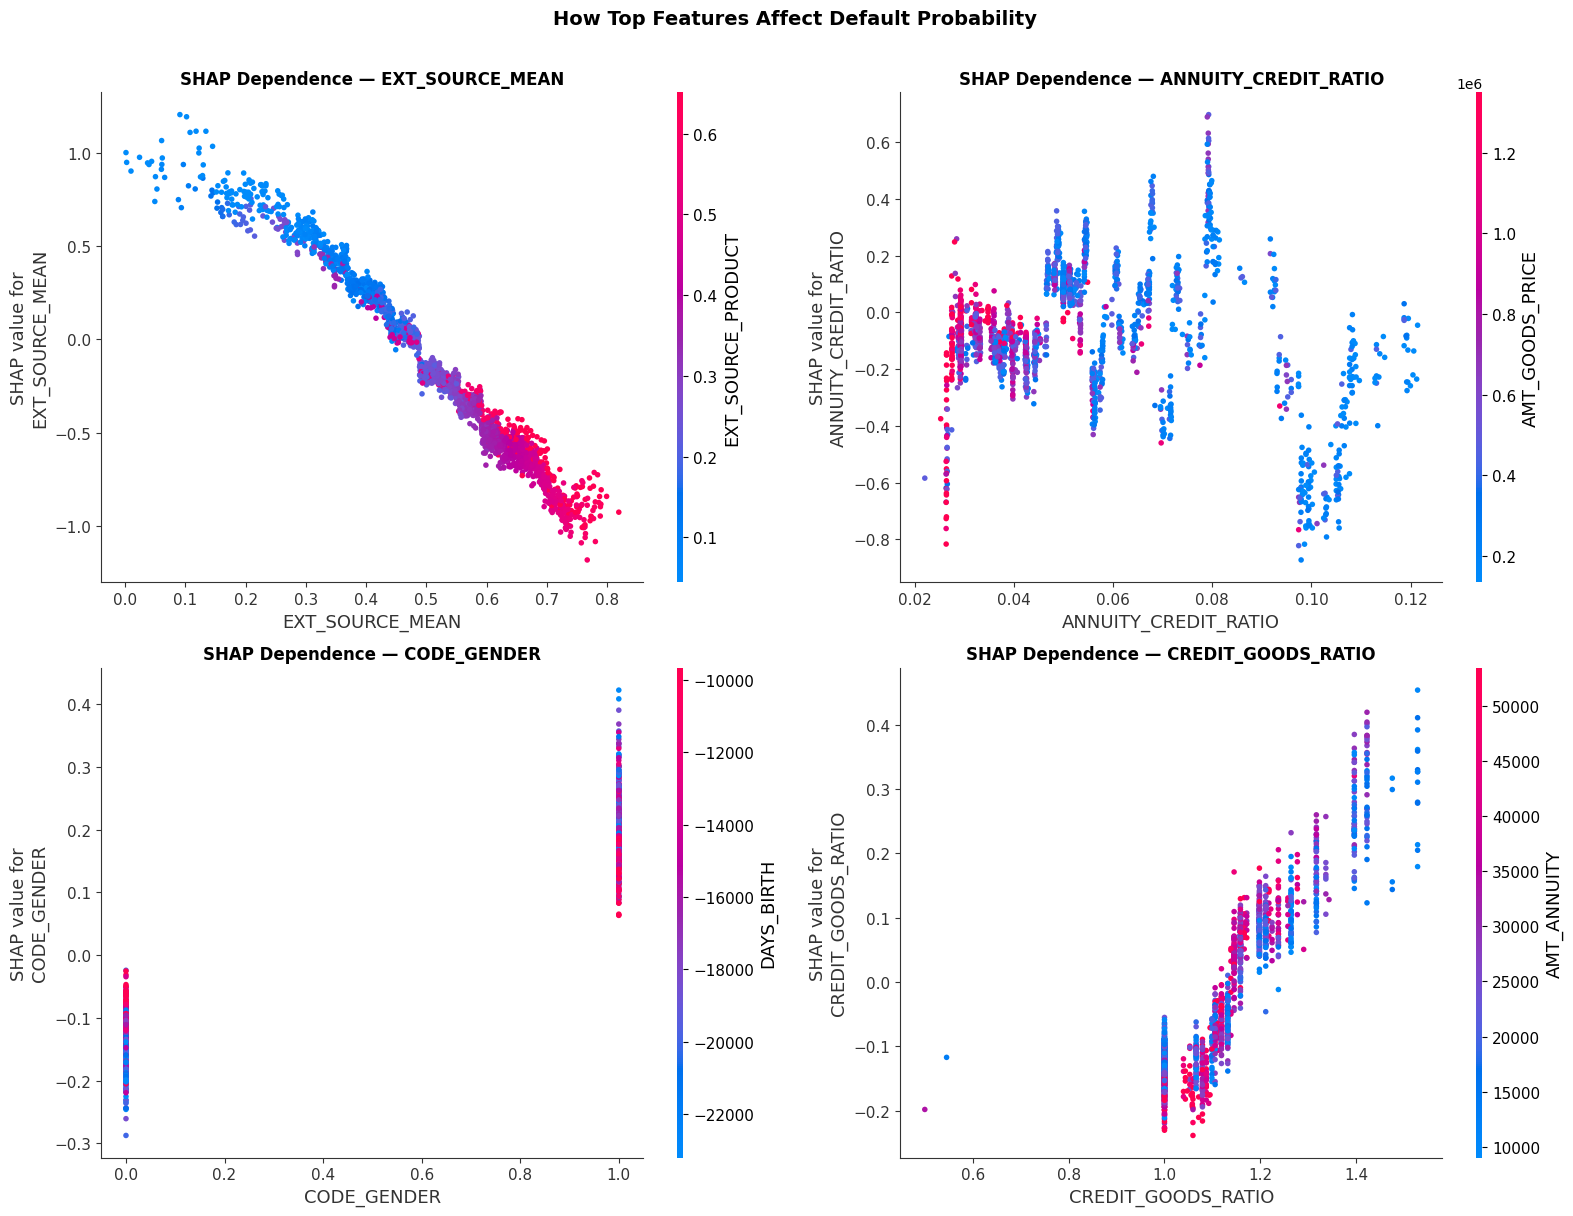

In [9]:
top_features = shap_importance['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_sample, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence — {feature}', fontweight='bold')

plt.suptitle('How Top Features Affect Default Probability',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 — High vs Low Risk Borrower Comparison

In [10]:
top10 = shap_importance['Feature'].head(10).tolist()

comparison = pd.DataFrame({
    'Feature'         : top10,
    'High-Risk Value' : X_sample.iloc[high_risk_idx][top10].values.round(3),
    'Low-Risk Value'  : X_sample.iloc[low_risk_idx][top10].values.round(3)
})

print(f'High-risk — P(default) = {y_prob_sample[high_risk_idx]:.4f}')
print(f'Low-risk  — P(default) = {y_prob_sample[low_risk_idx]:.4f}')
print()
print(comparison.to_string(index=False))

High-risk — P(default) = 0.9301
Low-risk  — P(default) = 0.0076

             Feature  High-Risk Value  Low-Risk Value
     EXT_SOURCE_MEAN            0.062           0.697
ANNUITY_CREDIT_RATIO            0.049           0.026
         CODE_GENDER            1.000           1.000
  CREDIT_GOODS_RATIO            1.422           1.000
 NAME_EDUCATION_TYPE            4.000           1.000
        EXT_SOURCE_3            0.066           0.645
  EXT_SOURCE_PRODUCT            0.004           0.483
        FLAG_OWN_CAR            1.000           1.000
     AMT_GOODS_PRICE       450000.000     1984500.000
         AMT_ANNUITY        31131.000       52348.500


## 8 — Risk Scoring Framework

Converts default probability into an actionable risk band. This is what surfaces to a loan officer — not a raw number, but a decision.

In [11]:
def get_risk_band(probability):
    if probability < 0.20:   return 'LOW',      'Approve'
    elif probability < 0.40: return 'MEDIUM',   'Review'
    elif probability < 0.60: return 'HIGH',     'Decline or require collateral'
    else:                    return 'CRITICAL', 'Decline'

def score_borrower(label, idx):
    prob = y_prob_sample[idx]
    band, action = get_risk_band(prob)
    shap_row = pd.Series(shap_values[idx], index=feature_list)
    top5 = shap_row.abs().sort_values(ascending=False).head(5)

    print(f'=== {label} ===')
    print(f'P(default)     : {prob:.4f}')
    print(f'Risk Band      : {band}')
    print(f'Recommendation : {action}')
    print(f'Top 5 Drivers:')
    for feat in top5.index:
        direction = 'increases' if shap_row[feat] > 0 else 'decreases'
        print(f'  {feat:<35} {direction} risk')
    print()

score_borrower('HIGH-RISK BORROWER', high_risk_idx)
score_borrower('LOW-RISK BORROWER',  low_risk_idx)

=== HIGH-RISK BORROWER ===
P(default)     : 0.9301
Risk Band      : CRITICAL
Recommendation : Decline
Top 5 Drivers:
  EXT_SOURCE_MEAN                     increases risk
  CREDIT_GOODS_RATIO                  increases risk
  EXT_SOURCE_PRODUCT                  increases risk
  ANNUITY_CREDIT_RATIO                increases risk
  EXT_SOURCE_3                        increases risk

=== LOW-RISK BORROWER ===
P(default)     : 0.0076
Risk Band      : LOW
Recommendation : Approve
Top 5 Drivers:
  EXT_SOURCE_MEAN                     decreases risk
  ANNUITY_CREDIT_RATIO                decreases risk
  DOCUMENT_COUNT                      decreases risk
  EXT_SOURCE_3                        decreases risk
  NAME_EDUCATION_TYPE                 decreases risk



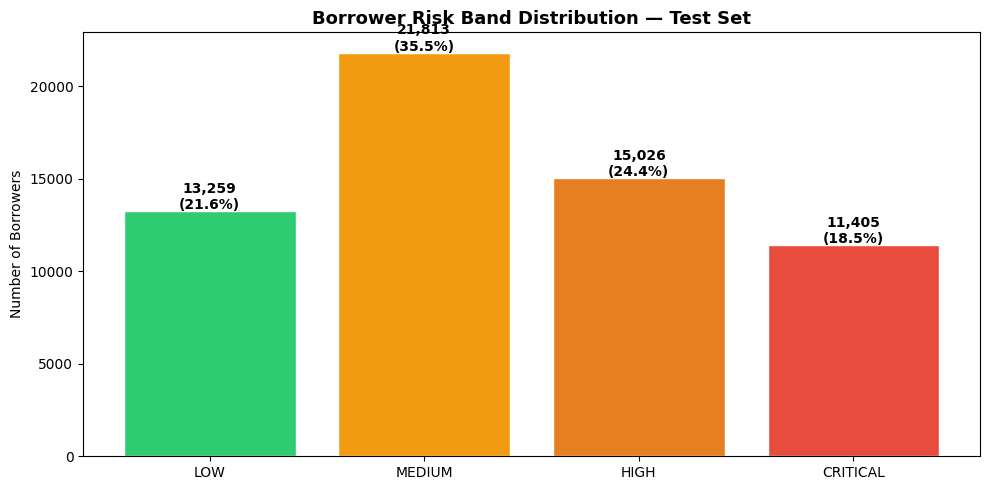

LOW         13259
MEDIUM      21813
HIGH        15026
CRITICAL    11405


In [12]:
all_probs  = model.predict_proba(X_test)[:, 1]
bands      = pd.Series([get_risk_band(p)[0] for p in all_probs])
band_counts = bands.value_counts().reindex(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'])

plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = plt.bar(band_counts.index, band_counts.values, color=colors, edgecolor='white')
plt.title('Borrower Risk Band Distribution — Test Set', fontsize=13, fontweight='bold')
plt.ylabel('Number of Borrowers')
for bar, val in zip(bars, band_counts.values):
    pct = val / len(all_probs) * 100
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}\n({pct:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/risk_band_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(band_counts.to_string())

## 9 — Summary

In [13]:
print('SHAP EXPLAINABILITY SUMMARY')
print('='*55)

print('\nTop 10 Features by Mean |SHAP Value|:')
print(shap_importance.head(10).to_string(index=False))

print(f"""
Risk Band Framework
  LOW      (<0.20)      : Approve
  MEDIUM   (0.20-0.40)  : Review
  HIGH     (0.40-0.60)  : Decline or require collateral
  CRITICAL (>0.60)      : Decline

Test Set Distribution
{band_counts.to_string()}
""")

SHAP EXPLAINABILITY SUMMARY

Top 10 Features by Mean |SHAP Value|:
             Feature  Mean |SHAP|
     EXT_SOURCE_MEAN     0.444277
ANNUITY_CREDIT_RATIO     0.172306
         CODE_GENDER     0.152799
  CREDIT_GOODS_RATIO     0.115695
 NAME_EDUCATION_TYPE     0.113466
        EXT_SOURCE_3     0.101307
  EXT_SOURCE_PRODUCT     0.096193
        FLAG_OWN_CAR     0.088547
     AMT_GOODS_PRICE     0.084073
         AMT_ANNUITY     0.069141

Risk Band Framework
  LOW      (<0.20)      : Approve
  MEDIUM   (0.20-0.40)  : Review
  HIGH     (0.40-0.60)  : Decline or require collateral
  CRITICAL (>0.60)      : Decline

Test Set Distribution
LOW         13259
MEDIUM      21813
HIGH        15026
CRITICAL    11405

